# Truncated NFW (TNFW) Potentials in `streamsculptor`

This notebook demonstrates `TNFWPotential` and `TNFWSubhaloLinePotential` from `streamsculptor.tnfw`.

These implement the tidally-stripped NFW profile:
$$\rho(r) = \frac{\rho_s f_t}{u(1+u)^2\left(1 + (r/r_t)^2\right)}, \quad u = r/r_s$$

Tidal track parameters follow **Du et al. 2024** (NFW $\alpha=1, \beta=3, \gamma=1, \delta=2$).

The potential is built via a spherical ($\ell=0$) basis function expansion using `bfeax`

**Requirements**
```bash
pip install git+https://github.com/jnibauer/bfeax.git
```

In [7]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import streamsculptor as ssc
from streamsculptor import potential
from streamsculptor.tnfw import TNFWPotential, TNFWSubhaloLinePotential
usys = ssc.usys

## 1. Build a single `TNFWPotential`

Two construction paths:
- `from_profile(rhos, rs, ft, rt)` — supply density profile parameters directly
- `from_infall(m_infall, c_infall, z_infall, f_bound)` — supply infall properties; tidal track (Du+2024) converts to profile parameters internally

In [2]:
# --- from infall properties ---
pot_tnfw = TNFWPotential.from_infall(
    m_infall = 1e8,   # Msun
    c_infall = 15.0,  # concentration at infall
    z_infall = 1.0,   # infall redshift
    f_bound  = 0.3,   # bound mass fraction at impact
    n_r      = 128,
)

xyz = jnp.array([0.5, 0.0, 0.0])   # kpc
print(f"Phi at {xyz}: {pot_tnfw.potential(xyz, 0.):.6e}  (kpc/Myr)^2")
print(f"Acc at {xyz}: {pot_tnfw.acceleration(xyz, 0.)}")

Phi at [0.5 0.  0. ]: -1.807377e-04  (kpc/Myr)^2
Acc at [0.5 0.  0. ]: [-0.00018788 -0.         -0.        ]


In [3]:
# --- from density profile params directly ---
pot_tnfw2 = TNFWPotential.from_profile(
    rhos = 2e7,   # Msun/kpc^3
    rs   = 0.5,   # kpc
    ft   = 0.4,
    rt   = 1.2,   # kpc
)
print(f"Phi at {xyz}: {pot_tnfw2.potential(xyz, 0.):.6e}")

Phi at [0.5 0.  0. ]: -4.298080e-05


## 2. Check density reconstruction

`density()` is inherited from `BFEPotential` (and ultimately from `Potential`) via the Laplacian of the potential. It should match the analytic TNFW density.

rhos=4.955e+07 Msun/kpc^3,  rs=0.444 kpc,  ft=0.927,  rt=1.035 kpc


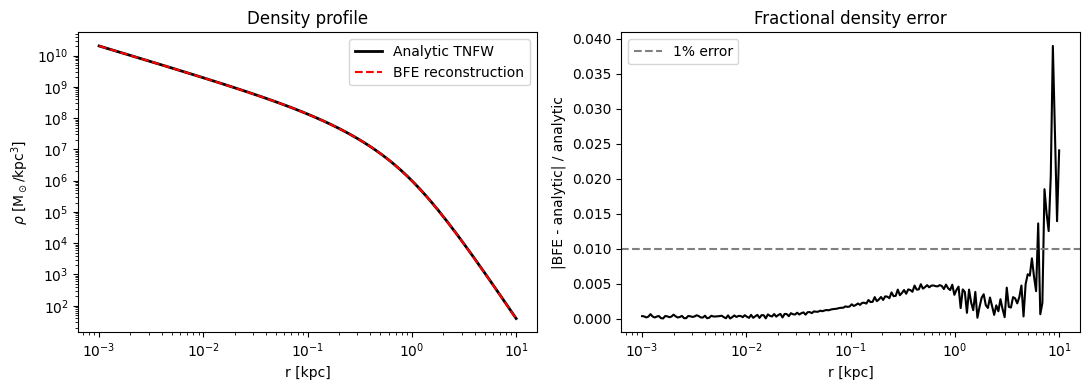

In [18]:
from streamsculptor.tnfw import _nfw_params_from_infall, _tidally_evolved_nfw_params

rhos, rs, ft, rt = _tidally_evolved_nfw_params(1e8, 15.0, 1.0, 0.3)
print(f"rhos={rhos:.3e} Msun/kpc^3,  rs={rs:.3f} kpc,  ft={ft:.3f},  rt={rt:.3f} kpc")

def tnfw_density_analytic(r):
    u = r / rs
    return rhos * ft / (u * (1 + u)**2 * (1 + (r / rt)**2))

r_plot = jnp.logspace(-3, 1, 200)

rho_bfe  = jax.vmap(lambda r: pot_tnfw.density(jnp.array([r, 0., 0.]), 0.))(r_plot)
rho_true = jax.vmap(tnfw_density_analytic)(r_plot)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(r_plot, rho_true, 'k-',  lw=2,   label='Analytic TNFW')
axes[0].loglog(r_plot, rho_bfe,  'r--', lw=1.5, label='BFE reconstruction')
axes[0].set_xlabel('r [kpc]')
axes[0].set_ylabel(r'$\rho$ [M$_\odot$/kpc$^3$]')
axes[0].set_title('Density profile')
axes[0].legend()

frac_err = np.abs(np.array(rho_bfe) - np.array(rho_true)) / np.array(rho_true)
axes[1].semilogx(r_plot, frac_err, 'k-')
axes[1].axhline(0.01, ls='--', color='gray', label='1% error')
axes[1].set_xlabel('r [kpc]')
axes[1].set_ylabel('|BFE - analytic| / analytic')
axes[1].set_title('Fractional density error')
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
# I did not realize this, but the tnfw actually has a closed form potential! 
# TODO: implement! For now, we can check the autodiff density against the analytic form and the BFE
def tnfw_potential(xyz, rhos, rs, ft, rt, G=usys.G):
    """
    Analytic 3D gravitational potential of the truncated NFW profile (Baltz+2009).
    """
    r = jnp.linalg.norm(xyz)
    # Prevent 1/0 NaN generation during autodiff at the exact core
    r = jnp.clip(r, a_min=1e-10)

    tau = rt / rs
    t2  = tau ** 2
    t2_m1 = t2 - 1
    t2_p1 = t2 + 1
    
    # The M0 = 4 * pi * rhos * ft * rs**3 mass definition,
    # divided by rs for the potential, combined with the global denominator
    prefactor = G * 4 * jnp.pi * rhos * ft * rs ** 2 * t2 / (t2_p1 ** 2)
    
    # The constant term ensures Phi -> 0 as r -> infinity
    term1 = jnp.pi * t2_m1 / (2 * tau) - jnp.log(t2)
    
    term3 = (2 - t2_m1 * rs / r) * jnp.log(1 + r / rs)
    term4 = (t2_m1 * rs / (2 * r) - 1) * jnp.log(1 + (r / rt) ** 2)
    term5 = -(t2_m1 / tau + 2 * rt / r) * jnp.arctan(r / rt)
    
    return prefactor * (term1 + term3 + term4 + term5)

def tnfw_density_autodiff(r_val):
    xyz = jnp.array([r_val, 0.0, 0.0])
    
    
    hessian_matrix = jax.hessian(tnfw_potential, argnums=0)(xyz, rhos, rs, ft, rt, usys.G)
    
    laplacian = jnp.trace(hessian_matrix)
    return laplacian / (4 * jnp.pi * usys.G)


/var/folders/mn/slwdcx9x3lv6wky78mz09pkw0000gp/T/ipykernel_66733/3450783864.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


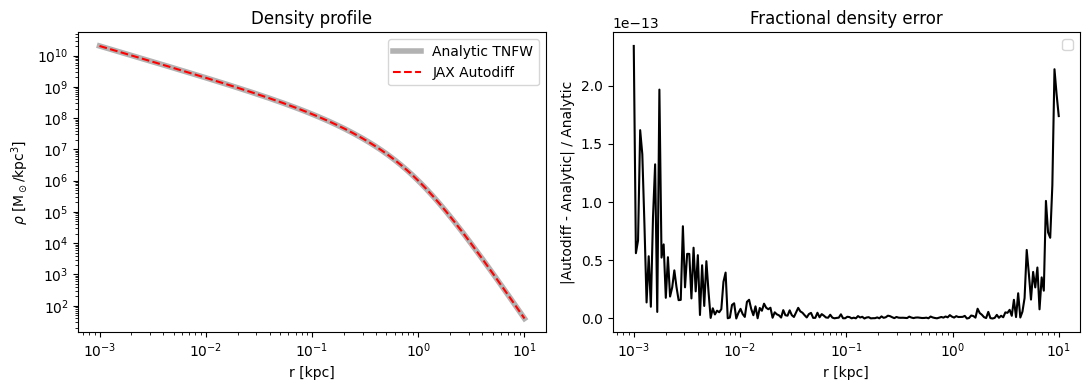

In [53]:
# --- PLOTTING ---
r_plot = jnp.logspace(-3, 1, 200)

# Evaluate both using vmap
rho_autodiff = jax.vmap(tnfw_density_autodiff)(r_plot)
rho_true     = jax.vmap(tnfw_density_analytic)(r_plot)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(r_plot, rho_true, 'k-',  lw=4, alpha=0.3, label='Analytic TNFW')
axes[0].loglog(r_plot, rho_autodiff,  'r--', lw=1.5, label='JAX Autodiff')
axes[0].set_xlabel('r [kpc]')
axes[0].set_ylabel(r'$\rho$ [M$_\odot$/kpc$^3$]')
axes[0].set_title('Density profile')
axes[0].legend()

# Calculate fractional error
frac_err = np.abs(np.array(rho_autodiff) - np.array(rho_true)) / np.array(rho_true)

axes[1].semilogx(r_plot, frac_err, 'k-')
axes[1].set_xlabel('r [kpc]')
axes[1].set_ylabel('|Autodiff - Analytic| / Analytic')
axes[1].set_title('Fractional density error')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Check enclosed mass via the BFE potential

The enclosed mass $M(<r)$ can be recovered from the radial force: $M(<r) = -r^2 F_r / G$.
We compare to the analytic TNFW enclosed mass formula.

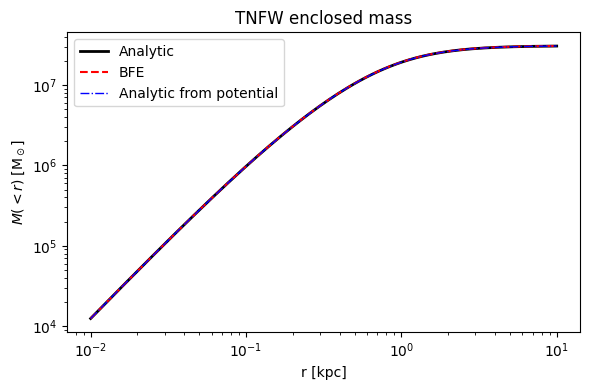

In [54]:
G = ssc.usys.G  # kpc^3 / (Msun Myr^2)

def enclosed_mass_bfe(r):
    xyz = jnp.array([r, 0., 0.])
    Fr = pot_tnfw.acceleration(xyz, 0.)[0]  # radial force (x-direction here)
    return -r**2 * Fr / G

def enclosed_mass_from_analytic_potential(r):
    xyz = jnp.array([r,0,0.])
    Fr = -jax.grad(tnfw_potential, argnums=0)(xyz, rhos, rs, ft, rt, G)[0]
    return -r**2 * Fr / G

def tnfw_enclosed_mass_analytic(R):
    tau = rt / rs
    u   = R / rs
    t2  = tau**2
    term1 = (t2 - 1) / (t2 + 1)**2 * jnp.log(1 + u)
    term2 = 1 / (t2 + 1) * (1 / (1 + u) - 1)
    term3 = -(t2 - 1) / (2 * (t2 + 1)**2) * jnp.log(1 + u**2 / t2)
    term4 = 2 * tau / (t2 + 1)**2 * jnp.arctan(u / tau)
    return 4 * jnp.pi * rhos * ft * rs**3 * t2 * (term1 + term2 + term3 + term4)

r_enc = jnp.logspace(-2, 1, 150)
M_bfe  = jax.vmap(enclosed_mass_bfe)(r_enc)
M_true = jax.vmap(tnfw_enclosed_mass_analytic)(r_enc)
M_analytic_from_potential = jax.vmap(enclosed_mass_from_analytic_potential)(r_enc)

plt.figure(figsize=(6, 4))
plt.loglog(r_enc, M_true, 'k-',  lw=2,   label='Analytic')
plt.loglog(r_enc, M_bfe,  'r--', lw=1.5, label='BFE')
plt.loglog(r_enc, M_analytic_from_potential, 'b-.', lw=1, label='Analytic from potential',zorder=5)
plt.xlabel('r [kpc]')
plt.ylabel(r'$M(<r)$ [M$_\odot$]')
plt.title('TNFW enclosed mass')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Timing: `TNFWPotential` acceleration

In [6]:
import equinox as eqx

In [7]:
acc_jit = eqx.filter_jit(pot_tnfw.acceleration)
xyz_test = jnp.array([0.5, 0.0, 0.0])
_ = jax.block_until_ready(acc_jit(xyz_test, 0.))  # warm up
%timeit jax.block_until_ready(acc_jit(xyz_test, 0.))

197 μs ± 3.74 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## 5. Build `TNFWSubhaloLinePotential`

Each subhalo moves on a straight-line trajectory and is active only within `t_window` of its impact time.

Construction builds N independent `TNFWPotential` (BFEPotential) objects — one per subhalo — stored in a static Python list. At eval time, a Python loop with `jax.lax.cond` gates each subhalo's contribution based on the time window.

In [9]:
import time

N = 50  # number of subhalos
key = jax.random.PRNGKey(42)

keys = jax.random.split(key, 8)
m_infall  = jnp.exp(jax.random.uniform(keys[0], (N,), minval=jnp.log(1e7), maxval=jnp.log(1e9)))
c_infall  = jax.random.uniform(keys[1], (N,), minval=10.0, maxval=25.0)
z_infall  = jax.random.uniform(keys[2], (N,), minval=0.5,  maxval=2.0)
f_bound   = jax.random.uniform(keys[3], (N,), minval=0.05, maxval=0.9)

# Random impact locations and velocities
x0 = jax.random.normal(keys[4], (N, 3)) * 10.0         # kpc
v0 = jax.random.normal(keys[5], (N, 3)) * 0.1          # kpc/Myr
t0 = jax.random.uniform(keys[6], (N,), minval=-2000., maxval=-500.)  # Myr

t_start = time.time()
pot_line = TNFWSubhaloLinePotential.from_infall(
    m_infall=m_infall, c_infall=c_infall, z_infall=z_infall, f_bound=f_bound,
    subhalo_x0=x0, subhalo_v=v0, subhalo_t0=t0,
    t_window=500.0,
    n_r=128,
)
print(f"Built {N} TNFW subhalos in {time.time()-t_start:.2f}s")
#print(f"Number of subhalo potentials: {len(pot_line.pots)}")
print(f"subhalo_x0 shape: {pot_line.subhalo_x0.shape}")
print(f"subhalo_v  shape: {pot_line.subhalo_v.shape}")

Built 50 TNFW subhalos in 0.02s
subhalo_x0 shape: (50, 3)
subhalo_v  shape: (50, 3)


In [10]:
# from_density_profiles classmethod: skip tidal track, supply (rhos, rs, ft, rt) directly
from streamsculptor.tnfw import _tidally_evolved_nfw_params

rhos_arr, rs_arr, ft_arr, rt_arr = _tidally_evolved_nfw_params(
    m_infall, c_infall, z_infall, f_bound
)

pot_line2 = TNFWSubhaloLinePotential(
    rhos=rhos_arr, rs=rs_arr, ft=ft_arr, rt=rt_arr,
    subhalo_x0=x0, subhalo_v=v0, subhalo_t0=t0,
    t_window=500.0,
)
print(f"Direct construction OK ")

Direct construction OK 


## 6. Evaluate `TNFWSubhaloLinePotential`

In [11]:
xyz_eval = jnp.array([8.0, 0.0, 0.0])
t_eval   = -800.0   # Myr — within t_window of some subhalos

# Warm up (potential and acceleration are @eqx.filter_jit / base-class autodiff)
_ = jax.block_until_ready(pot_line.potential(xyz_eval, t_eval))
_ = jax.block_until_ready(pot_line.acceleration(xyz_eval, t_eval))

print(f"Phi (sum over all SH): {pot_line.potential(xyz_eval, t_eval):.6e}  (kpc/Myr)^2")
print(f"Acc (sum over all SH): {pot_line.acceleration(xyz_eval, t_eval)}")

Phi (sum over all SH): -4.712013e-04  (kpc/Myr)^2
Acc (sum over all SH): [-8.89398583e-06 -1.15209630e-06 -5.66699006e-06]


In [12]:
import equinox as eqx
jitted_acc = eqx.filter_jit(pot_line.acceleration)
_ = jax.block_until_ready(jitted_acc(xyz_eval, t_eval))

In [13]:
%timeit jax.block_until_ready(jitted_acc(xyz_eval, t_eval))

228 μs ± 5.72 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Active subhalos at t=-800.0 Myr: 30 / 50


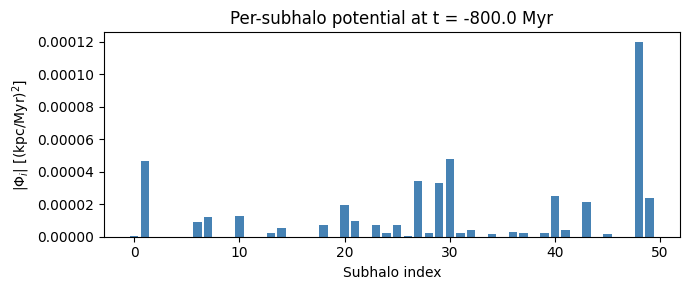

In [14]:
# Per-subhalo potential breakdown
per_sh = pot_line.potential_per_SH(xyz_eval, t_eval)
active = jnp.abs(per_sh) > 0
print(f"Active subhalos at t={t_eval} Myr: {int(active.sum())} / {N}")

plt.figure(figsize=(7, 3))
plt.bar(jnp.arange(N), jnp.abs(per_sh), color='steelblue', width=0.8)
plt.xlabel('Subhalo index')
plt.ylabel(r'$|\Phi_i|$ [(kpc/Myr)$^2$]')
plt.title(f'Per-subhalo potential at t = {t_eval} Myr')
plt.tight_layout()
plt.show()

## 7. Stream with TNFW subhalo perturbation

We combine the Milky Way potential with a `TNFWSubhaloLinePotential` and generate a perturbed stream using `gen_stream_scan_with_pert`.

In [15]:
from streamsculptor import usys


In [16]:

pot_MW = potential.GalaMilkyWayPotential(units=usys)

# Progenitor
w_today = jnp.array([20.0, 0.0, 20.0, 0.0, 0.15, 0.0])
t_age   = 3_500  # Myr
ts_back = jnp.linspace(0, -t_age, 1000)
IC = pot_MW.integrate_orbit(w0=w_today, ts=ts_back, t0=0.0, t1=-t_age,).ys[-1]
print('IC:', IC)

IC: [ -7.23544156  -7.96290672 -10.81798608   0.19179774  -0.2035431
  -0.01775124]


In [17]:
# Unperturbed stream
t_strip  = jnp.linspace(-t_age, 0, 3000)
Mcluster = jnp.linspace(1e4, 0.0, len(t_strip))

lead_base, trail_base = pot_MW.gen_stream_scan(
    ts=t_strip, prog_w0=IC, Msat=Mcluster, seed_num=42
)
stream_base = jnp.vstack([lead_base, trail_base])

In [18]:
# Build a single TNFW subhalo that impacts the stream
t_impact = -1200.0  # Myr

# Pick an impact location along the stream: take a segment and integrate it back
seg_mask = (stream_base[:, 1] > -6) & (stream_base[:, 1] < -5)
avg_w = stream_base[seg_mask].mean(axis=0)
w_impact = pot_MW.integrate_orbit(
    w0=avg_w, ts=jnp.array([0.0, t_impact]), t0=0.0, t1=t_impact
).ys[-1]

# Subhalo slightly offset in velocity
w_sh = w_impact + jnp.array([0., 0., 0., 0.02, 0., 0.02])

pot_TNFW_sh = TNFWSubhaloLinePotential.from_infall(
    m_infall  = jnp.array([5e7]),
    c_infall  = jnp.array([18.0]),
    z_infall  = jnp.array([1.0]),
    f_bound   = jnp.array([0.4]),
    subhalo_x0 = jnp.array([w_sh[:3]]),
    subhalo_v  = jnp.array([w_sh[3:]]),
    subhalo_t0 = jnp.array([t_impact]),
    t_window   = 300.0,
)
print("TNFW subhalo built")

TNFW subhalo built


In [19]:
# Perturbed stream
lead_pert, trail_pert = ssc.gen_stream_scan_with_pert(
    pot_base=pot_MW, pot_pert=pot_TNFW_sh,
    ts=t_strip, prog_w0=IC, Msat=Mcluster, seed_num=42,
)
stream_pert = jnp.vstack([lead_pert, trail_pert])

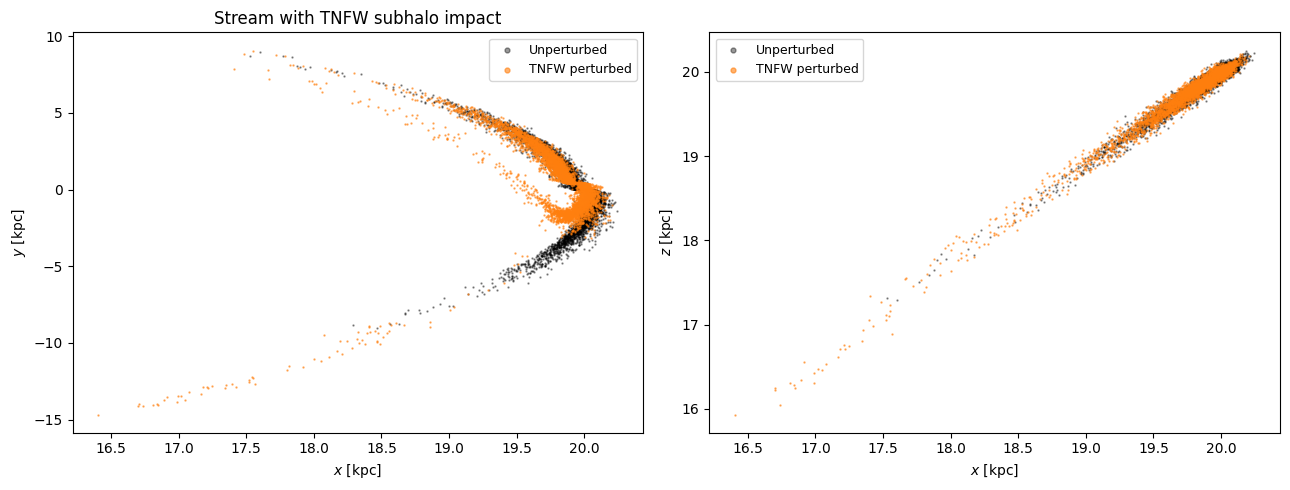

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (i, j, xl, yl) in zip(axes, [(0,1,'x','y'), (0,2,'x','z')]):
    ax.scatter(stream_base[:, i], stream_base[:, j],
               s=0.5, color='k', alpha=0.4, label='Unperturbed')
    ax.scatter(stream_pert[:, i], stream_pert[:, j],
               s=0.5, color='C1', alpha=0.6, label='TNFW perturbed')
    ax.set_xlabel(f'${xl}$ [kpc]')
    ax.set_ylabel(f'${yl}$ [kpc]')
    ax.legend(markerscale=5, fontsize=9)

axes[0].set_title('Stream with TNFW subhalo impact')
plt.tight_layout()
plt.show()

## 8. Combine with the MW potential

`TNFWSubhaloLinePotential` is a standard `Potential`, so it composes with `Potential_Combine`.

In [21]:
pot_total = potential.Potential_Combine(
    potential_list=[pot_MW, pot_TNFW_sh],
    units=usys,
)

xyz_test = jnp.array([8.0, 0.0, 0.0])
t_test   = -1200.0
print(f"MW alone:    Phi = {pot_MW.potential(xyz_test, t_test):.6e}")
print(f"TNFW SH:     Phi = {pot_TNFW_sh.potential(xyz_test, t_test):.6e}")
print(f"Combined:    Phi = {pot_total.potential(xyz_test, t_test):.6e}")

MW alone:    Phi = -1.644030e-01
TNFW SH:     Phi = -6.874721e-06
Combined:    Phi = -1.644098e-01


## 9. Differentiability

All methods are fully differentiable through JAX. 

In [22]:
import equinox as eqx

grad_fn = jax.jit(jax.grad(pot_TNFW_sh.potential, argnums=0))
grad_xyz = grad_fn(jnp.array([0.3, 0.0, 0.0]), -1200.0)
print(f"grad_phi w.r.t. xyz: {grad_xyz}")
print("(should match acceleration with flipped sign)")
print(f"acceleration:        {pot_TNFW_sh.acceleration(jnp.array([0.3,0.,0.]), -1200.)}") 

grad_phi w.r.t. xyz: [-1.98548291e-07 -8.62642959e-08 -2.21288567e-07]
(should match acceleration with flipped sign)
acceleration:        [1.98548291e-07 8.62642959e-08 2.21288567e-07]
